data.shape (1, 20, 17, 4)
obs_data.shape (1, 8, 17, 4)
---------------------------
ma_data 
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
ma_data.shape (8, 2)
plot_data.shape (8, 2)


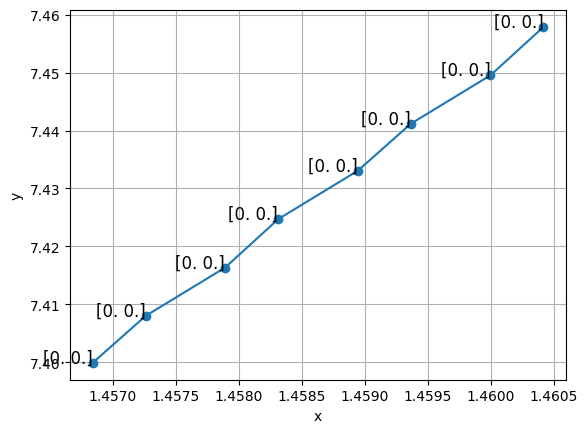

In [10]:
import numpy as np 
from matplotlib import pyplot as plt 
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
# 加载 npy 文件
obs_seq_len = 8 
data = np.load('seq_ma.npy') # [batch, obs_len+pred_len, num_ped, 4] 
print('data.shape', data.shape) 

obs_data = data[:, :obs_seq_len, :, :] 
pred_data = data[:, obs_seq_len:, :, :] 
print('obs_data.shape', obs_data.shape) # [batch, obs_len, num_ped, 4] 

obs_data = obs_data.squeeze(0) # [obs_len, num_ped, 4] 
i = 0 # the ith ped 
plot_data = obs_data[:, i, :2] # [obs_len, num_ped, 2] 
ma_data = obs_data[:, i, 2:] # [obs_len, num_ped, 2] 


print('---------------------------') 
print('ma_data \n', ma_data) 
print('ma_data.shape',ma_data.shape)
print('plot_data.shape', plot_data.shape)

# 绘制折线图
plt.plot(plot_data[:, 0], plot_data[:, 1], marker='o')

# 在每个点旁边添加标签
for j, (x, y) in enumerate(plot_data):
    plt.text(x, y, str(ma_data[j]), fontsize=12, ha='right')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
# 显示图形
plt.show()


In [12]:
obs_traj = np.load('obs_traj.npy') # [batch, obs_len, num_ped, 2]
obs_traj_rel = np.load('obs_traj_rel.npy') # [batch, obs_len, num_ped, 2]
print('obs_traj.shape', obs_traj.shape)
print('obs_traj_rel.shape', obs_traj_rel.shape)
i = 0 # the ith ped 
plot_data
#### 画出两个轨迹，比较相对位置和绝对位置的区别


obs_traj.shape (1, 2, 2, 8)
obs_traj_rel.shape (1, 2, 2, 8)


Models being tested are: ['./checkpoint/stcrf_eth']
exp_path: ./checkpoint/stcrf_eth
**************************************************
Evaluating model: ./checkpoint/stcrf_eth
[3.6267974375289933, 5.13982013126341, 5.291724437897442, 5.404219633170539, 5.462728155672268, 5.534525282116963, 5.559941717413649, 5.567804414255977, 5.611841013076156, 5.614695485079754, 5.6111351628280355, 5.633542203801512, 5.621862968547432, 5.590670410543772, 5.626889259052633, 5.652792026123075, 5.62799484719308, 5.671913837450113, 5.6474268310166895, 5.6346912172461545, 5.630665010361219, 5.65898924346408, 5.65514340496473, 5.645675248886742, 5.655060375307084, 5.638525086137561, 5.656723385717646, 5.681924927480647, 5.619928486630549, 5.666213165088463, 5.66037801452927, 5.662009885504891, 5.663856704968671, 5.656056639369069, 5.656724547680416, 5.631415884053594, 5.657164486453093, 5.659914011861351, 5.635928559600149, 5.676927495781589, 5.656976506047171, 5.665858019447933, 5.68018272118664, 5.63935

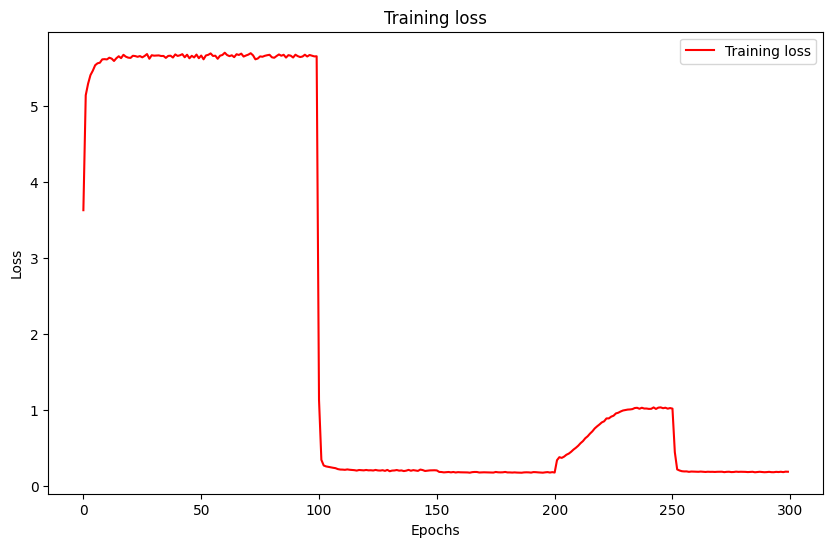

In [1]:
#### plot train loss 
import glob
import pickle
import matplotlib.pyplot as plt
# paths = [
#     './checkpoint/stcrf_eth',
#     './checkpoint/stcrf_hotel',
#     './checkpoint/stcrf_univ',
#     './checkpoint/stcrf_zara1',
#     './checkpoint/stcrf_zara2',
# ]
paths = [
    './checkpoint/stcrf_eth'
]

for feta in range(len(paths)):

    ade_ls = []
    fde_ls = []
    exp_ls = []
    path = paths[feta]
    exps = glob.glob(path)
    exps.sort()
    print('Models being tested are:', exps)

    for exp_path in exps:
        print('exp_path:',exp_path)

        # try:

        print("*" * 50)
        print("Evaluating model:", exp_path)

        # model_path = exp_path + '/val_best.pth'
        # args_path = exp_path + '/args.pkl'
        metrics_path = exp_path + '/metrics.pkl'
        # print the training loss in metrics file
        with open(metrics_path, 'rb') as f:
            metrics = pickle.load(f)
            print(metrics['train_loss'])
            ## plot train loss
            # plt.plot(metrics['train_loss'], label='train_loss')
            epochs = range(len(metrics['train_loss']))

plt.figure(figsize=(10, 6))
plt.plot(epochs, metrics['train_loss'], 'r', label='Training loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



Models being tested are: ['./checkpoint/stcrf_eth']
exp_path: ./checkpoint/stcrf_eth
**************************************************
Evaluating model: ./checkpoint/stcrf_eth


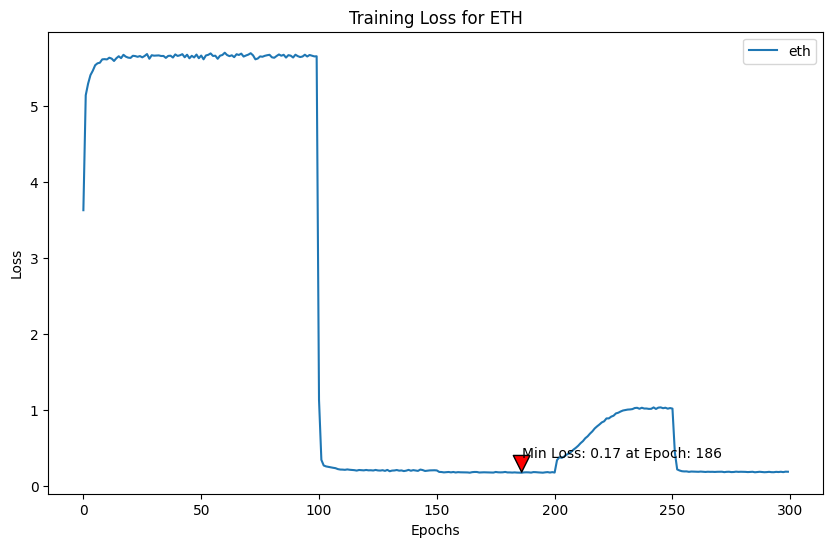

In [2]:
import glob
import pickle
import matplotlib.pyplot as plt

# Define paths to the checkpoints
# paths = [
#     './checkpoint/stcrf_eth',
#     './checkpoint/stcrf_hotel',
#     './checkpoint/stcrf_univ',
#     './checkpoint/stcrf_zara1',
#     './checkpoint/stcrf_zara2',
# ]
paths = [
    './checkpoint/stcrf_eth'
]

# Define labels for each path based on the last part of the path string
labels = [path.split('_')[-1] for path in paths]

plt.figure(figsize=(10, 6))

# Loop through each path and its corresponding label
for path, label in zip(paths, labels):
    exps = glob.glob(path)
    exps.sort()
    print('Models being tested are:', exps)

    for exp_path in exps:
        print('exp_path:', exp_path)
        print("*" * 50)
        print("Evaluating model:", exp_path)

        # Path to the metrics file
        metrics_path = exp_path + '/metrics.pkl'

        # Load the training loss from the metrics file
        with open(metrics_path, 'rb') as f:
            metrics = pickle.load(f)
            # Plot the training loss with the corresponding label
            epochs = range(len(metrics['train_loss']))
            plt.plot(epochs, metrics['train_loss'], label=label)

            # Find the minimum training loss and the corresponding epoch
            min_loss = min(metrics['train_loss'])
            min_epoch = metrics['train_loss'].index(min_loss)
            plt.annotate(f'Min Loss: {min_loss:.2f} at Epoch: {min_epoch}',
                         xy=(min_epoch, min_loss), xytext=(min_epoch, min_loss+0.2),
                         arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('Training Loss for ETH')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Models being tested are: ['./checkpoint/stcrf_eth']
exp_path: ./checkpoint/stcrf_eth
**************************************************
Evaluating model: ./checkpoint/stcrf_eth


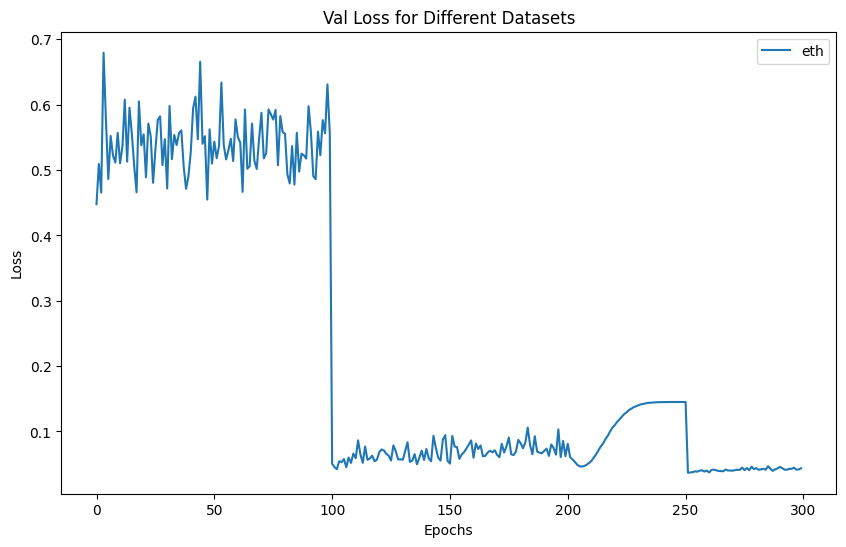

In [3]:
#### val_loss plot
import glob
import pickle
import matplotlib.pyplot as plt

# paths = [
#     './checkpoint/stcrf_eth',
#     './checkpoint/stcrf_hotel',
#     './checkpoint/stcrf_univ',
#     './checkpoint/stcrf_zara1',
#     './checkpoint/stcrf_zara2',
# ]
paths = [
    './checkpoint/stcrf_eth',
]
# Define labels for each path based on the last part of the path string
labels = [path.split('_')[-1] for path in paths]

plt.figure(figsize=(10, 6))

# Loop through each path and its corresponding label
for path, label in zip(paths, labels):
    exps = glob.glob(path)
    exps.sort()
    print('Models being tested are:', exps)

    for exp_path in exps:
        print('exp_path:', exp_path)
        print("*" * 50)
        print("Evaluating model:", exp_path)

        # Path to the metrics file
        metrics_path = exp_path + '/metrics.pkl'

        # Load the training loss from the metrics file
        with open(metrics_path, 'rb') as f:
            metrics = pickle.load(f)
            # Plot the training loss with the corresponding label
            epochs = range(len(metrics['val_loss']))
            plt.plot(epochs, metrics['val_loss'], label=label)

plt.title('Val Loss for Different Datasets')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Models being tested are: ['./checkpoint/stcrf_zara2']
exp_path: ./checkpoint/stcrf_zara2
**************************************************
Evaluating model: ./checkpoint/stcrf_zara2


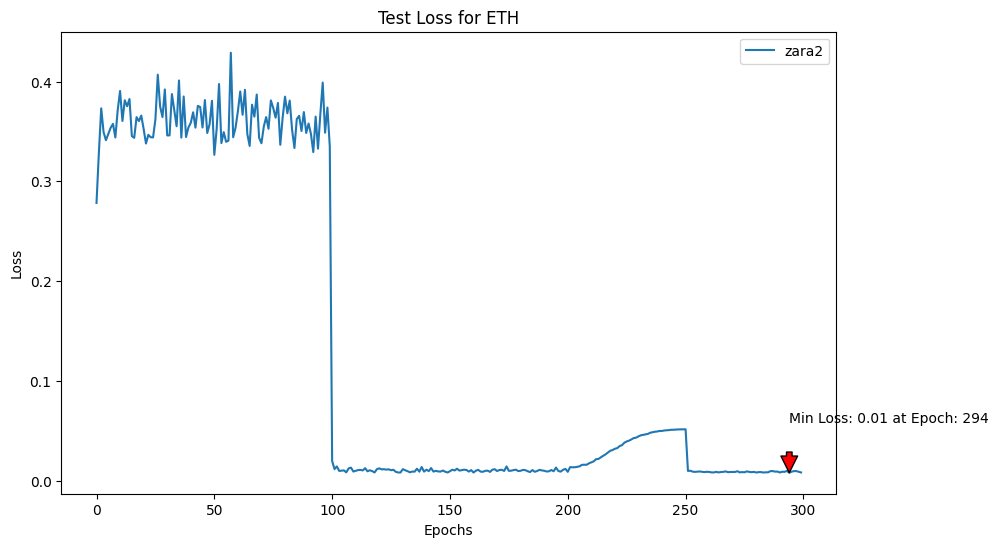

In [9]:
import glob
import pickle
import matplotlib.pyplot as plt

# Define paths to the checkpoints
# paths = [
#     './checkpoint/stcrf_eth',
#     './checkpoint/stcrf_hotel',
#     './checkpoint/stcrf_univ',
#     './checkpoint/stcrf_zara1',
#     './checkpoint/stcrf_zara2',
# ]
paths = [
    './checkpoint/stcrf_zara2'
]

# Define labels for each path based on the last part of the path string
labels = [path.split('_')[-1] for path in paths]

plt.figure(figsize=(10, 6))

# Loop through each path and its corresponding label
for path, label in zip(paths, labels):
    exps = glob.glob(path)
    exps.sort()
    print('Models being tested are:', exps)

    for exp_path in exps:
        print('exp_path:', exp_path)
        print("*" * 50)
        print("Evaluating model:", exp_path)

        # Path to the metrics file
        metrics_path = exp_path + '/metrics.pkl'

        # Load the training loss from the metrics file
        with open(metrics_path, 'rb') as f:
            metrics = pickle.load(f)
            # Plot the training loss with the corresponding label
            epochs = range(len(metrics['val_loss']))
            plt.plot(epochs, metrics['val_loss'], label=label)

            # Find the minimum training loss and the corresponding epoch
            min_loss = min(metrics['val_loss'])
            min_epoch = metrics['val_loss'].index(min_loss)
            plt.annotate(f'Min Loss: {min_loss:.2f} at Epoch: {min_epoch}',
                         xy=(min_epoch, min_loss), xytext=(min_epoch, min_loss+0.05 ),
                         arrowprops=dict(facecolor='red', shrink=0.5))

plt.title('Test Loss for ETH')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Models being tested are: ['./checkpoint/stcrf_eth']
exp_path: ./checkpoint/stcrf_eth
**************************************************
Evaluating model: ./checkpoint/stcrf_eth


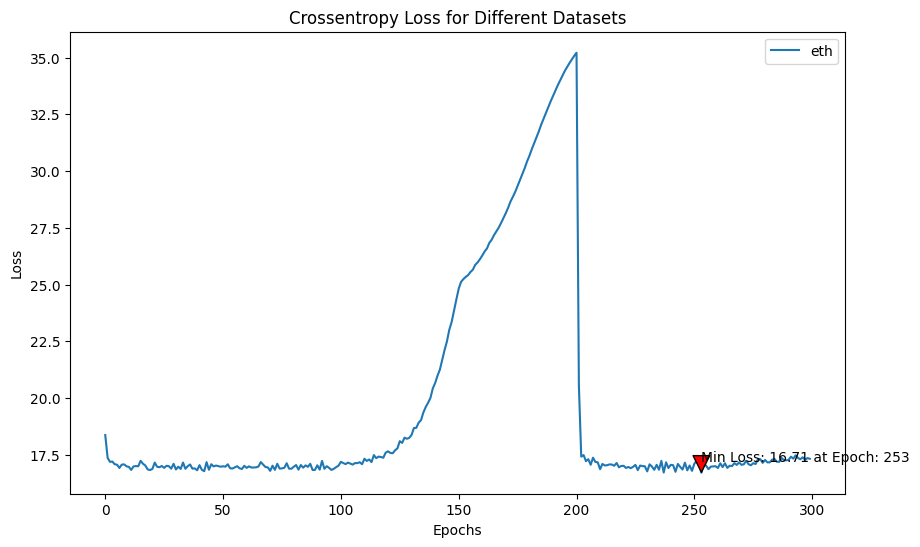

In [5]:
import glob
import pickle
import matplotlib.pyplot as plt

# Define paths to the checkpoints
# paths = [
#     './checkpoint/stcrf_eth',
#     './checkpoint/stcrf_hotel',
#     './checkpoint/stcrf_univ',
#     './checkpoint/stcrf_zara1',
#     './checkpoint/stcrf_zara2',
# ]
paths = [
    './checkpoint/stcrf_eth'
]

# Define labels for each path based on the last part of the path string
labels = [path.split('_')[-1] for path in paths]

plt.figure(figsize=(10, 6))

# Loop through each path and its corresponding label
for path, label in zip(paths, labels):
    exps = glob.glob(path)
    exps.sort()
    print('Models being tested are:', exps)

    for exp_path in exps:
        print('exp_path:', exp_path)
        print("*" * 50)
        print("Evaluating model:", exp_path)

        # Path to the metrics file
        metrics_path = exp_path + '/metrics.pkl'

        # Load the training loss from the metrics file
        with open(metrics_path, 'rb') as f:
            metrics = pickle.load(f)
            # Plot the training loss with the corresponding label
            epochs = range(len(metrics['crf_loss']))
            plt.plot(epochs, metrics['crf_loss'], label=label)

            # Find the minimum training loss and the corresponding epoch
            min_loss = min(metrics['crf_loss'])
            min_epoch = metrics['crf_loss'].index(min_loss)
            plt.annotate(f'Min Loss: {min_loss:.2f} at Epoch: {min_epoch}',
                         xy=(min_epoch, min_loss), xytext=(min_epoch, min_loss + 0.5),
                         arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('Crossentropy Loss for Different Datasets')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
